In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
data=pd.read_csv("data/Simple_linear _regression.csv", delimiter=",")

In [21]:
data

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.40,75,10.0
1,1664.0,2.52,80,12.0
2,1760.0,NaN,60,15.0
3,1685.0,2.74,90,18.0
4,1693.0,2.83,85,14.0
...,...,...,...,...
82,1962.0,3.76,97,28.0
83,2050.0,3.81,100,35.0
84,10.0,3.50,50,5.0
85,1900.0,48.00,95,30.0


In [22]:
print(data.shape)

(87, 4)


**DATA CLEANING**

Identify Columns That Contain a Single Value¶

In [23]:
n_cols=data.shape[1]
for i in range(n_cols):
    unique_values=np.unique(data.iloc[:,i])
    print('column',i,'has',len(unique_values),'unique values')

column 0 has 76 unique values
column 1 has 48 unique values
column 2 has 30 unique values
column 3 has 26 unique values


In [24]:
data.nunique()

SAT            75
GPA            47
Attendance     30
Study_Hours    25
dtype: int64

In [25]:
path='data/Simple_linear _regression.csv'
df = pd.read_csv(path)
df

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.40,75,10.0
1,1664.0,2.52,80,12.0
2,1760.0,NaN,60,15.0
3,1685.0,2.74,90,18.0
4,1693.0,2.83,85,14.0
...,...,...,...,...
82,1962.0,3.76,97,28.0
83,2050.0,3.81,100,35.0
84,10.0,3.50,50,5.0
85,1900.0,48.00,95,30.0


Delete Columns That Contain a Single Value

In [26]:
print(df.shape)
counts = df.nunique()
to_del = [i for i, v in enumerate(counts) if v==1]
print(to_del)
df.drop(df.columns[to_del],axis=1,inplace=True)
print(df.shape)

(87, 4)
[]
(87, 4)


Consider Columns That Have Very Few Values

In [27]:
for i in range(data.shape[1]):
    num_u=len(np.unique(data.iloc[:,i]))
    percentage=num_u/data.shape[0]*100
    print(i,num_u,round(percentage,2),'%')

0 76 87.36 %
1 48 55.17 %
2 30 34.48 %
3 26 29.89 %


Remove Columns That Have A Low Variance

In [28]:
to_del = [i for i,v in enumerate(counts) if (v/ df.shape[0])*100<1]
print(to_del)
df.drop(df.columns[to_del],axis=1,inplace=True)
print(df.shape)

[]
(87, 4)


Identify Rows That Contain Duplicate Data

In [29]:
dups = df.duplicated()
print(dups)
print(dups.any())
print(df[dups])

0     False
1     False
2     False
3     False
4     False
      ...  
82    False
83    False
84    False
85    False
86    False
Length: 87, dtype: bool
True
      SAT  GPA  Attendance  Study_Hours
7  1764.0  3.0         100         25.0


Delete Rows That Contain Duplicate Data

In [30]:
df.drop_duplicates(inplace=True)
print(df.shape)

(86, 4)


 Remove the columns where elements are missing (NaN)

In [31]:
df1 = df.dropna()
df1

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.40,75,10.0
1,1664.0,2.52,80,12.0
3,1685.0,2.74,90,18.0
4,1693.0,2.83,85,14.0
6,1764.0,3.00,100,25.0
...,...,...,...,...
82,1962.0,3.76,97,28.0
83,2050.0,3.81,100,35.0
84,10.0,3.50,50,5.0
85,1900.0,48.00,95,30.0


Fill all missing values

In [32]:
data['SAT'] = data['SAT'].fillna(data['SAT'].mean())
data['GPA'] = data['GPA'].fillna(data['GPA'].mean())
data['Attendance'] = data['Attendance'].fillna(data['Attendance'].mean())
data['Study_Hours'] = data['Study_Hours'].fillna(data['Study_Hours'].mean())
data

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.400000,75,10.0
1,1664.0,2.520000,80,12.0
2,1760.0,3.868353,60,15.0
3,1685.0,2.740000,90,18.0
4,1693.0,2.830000,85,14.0
...,...,...,...,...
82,1962.0,3.760000,97,28.0
83,2050.0,3.810000,100,35.0
84,10.0,3.500000,50,5.0
85,1900.0,48.000000,95,30.0


In [33]:
print(data.isnull().sum())

SAT            0
GPA            0
Attendance     0
Study_Hours    0
dtype: int64


Display information about the data

In [34]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SAT          87 non-null     float64
 1   GPA          87 non-null     float64
 2   Attendance   87 non-null     int64  
 3   Study_Hours  87 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.8 KB
None


Remove the unrealistic outlier

In [35]:
data = data[(data['GPA'] <= 4.0) & (data['SAT'] >= 400) & (data['Attendance'] <= 100)]
data

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.400000,75,10.0
1,1664.0,2.520000,80,12.0
2,1760.0,3.868353,60,15.0
3,1685.0,2.740000,90,18.0
4,1693.0,2.830000,85,14.0
...,...,...,...,...
79,1936.0,3.710000,95,27.0
80,1810.0,3.710000,88,20.0
81,1987.0,3.730000,99,30.0
82,1962.0,3.760000,97,28.0


In [36]:
print(data.describe())

               SAT        GPA  Attendance  Study_Hours
count    84.000000  84.000000   84.000000    84.000000
mean   1847.131921   3.352937   89.630952    21.564230
std     102.749557   0.269608    8.025231     5.829314
min    1634.000000   2.400000   60.000000    10.000000
25%    1774.500000   3.197500   85.750000    18.000000
50%    1846.000000   3.390000   91.000000    22.000000
75%    1934.000000   3.512500   95.250000    26.000000
max    2050.000000   3.868353  100.000000    35.000000


In [37]:
data

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.400000,75,10.0
1,1664.0,2.520000,80,12.0
2,1760.0,3.868353,60,15.0
3,1685.0,2.740000,90,18.0
4,1693.0,2.830000,85,14.0
...,...,...,...,...
79,1936.0,3.710000,95,27.0
80,1810.0,3.710000,88,20.0
81,1987.0,3.730000,99,30.0
82,1962.0,3.760000,97,28.0


In [38]:
print(data.head(10))

           SAT       GPA  Attendance  Study_Hours
0  1714.000000  2.400000          75    10.000000
1  1664.000000  2.520000          80    12.000000
2  1760.000000  3.868353          60    15.000000
3  1685.000000  2.740000          90    18.000000
4  1693.000000  2.830000          85    14.000000
5  1826.081395  2.910000          70    21.395349
6  1764.000000  3.000000         100    25.000000
7  1764.000000  3.000000         100    25.000000
8  1792.000000  3.010000          88    20.000000
9  1850.000000  3.010000          92    22.000000


**Data_Visualisation**

Scatter Plot

Text(0, 0.5, 'GPA')

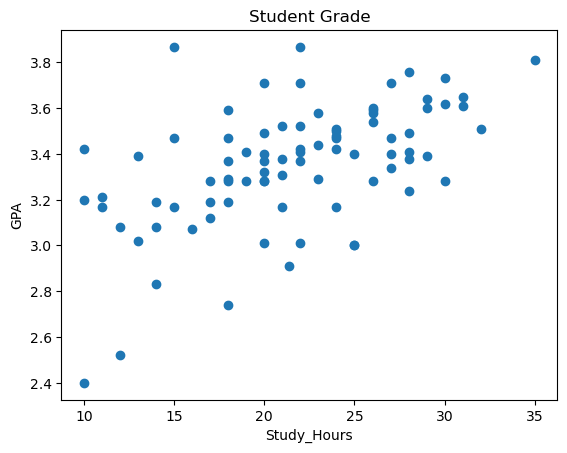

In [39]:
fig, ax = plt.subplots()
ax.scatter(data['Study_Hours'], data['GPA'])
ax.set_title('Student Grade')
ax.set_xlabel('Study_Hours')
ax.set_ylabel('GPA')

Histogram

Text(0, 0.5, 'GPA')

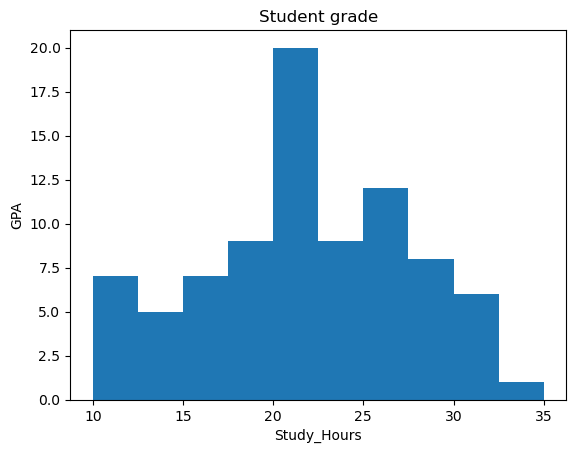

In [40]:

fig, ax = plt.subplots()
ax.hist(data['Study_Hours'])
ax.set_title('Student grade')
ax.set_xlabel('Study_Hours')
ax.set_ylabel('GPA')

Bar Chart

<AxesSubplot:>

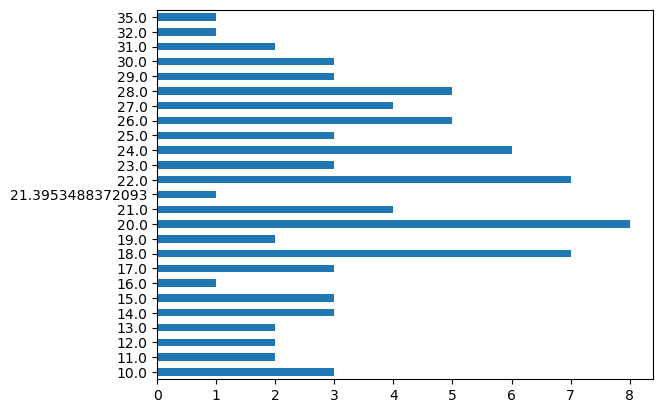

In [41]:
data['Study_Hours'].value_counts().sort_index().plot.barh()

<AxesSubplot:>

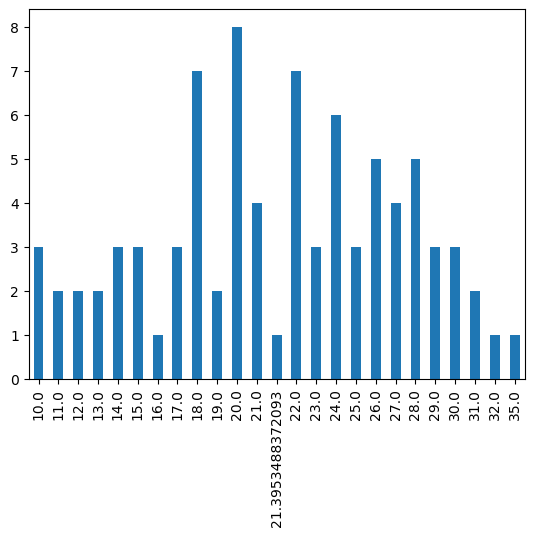

In [42]:
points_counts = data['Study_Hours'].value_counts()
points_sorted = points_counts.sort_index()
points_sorted.plot.bar()

Line Chart

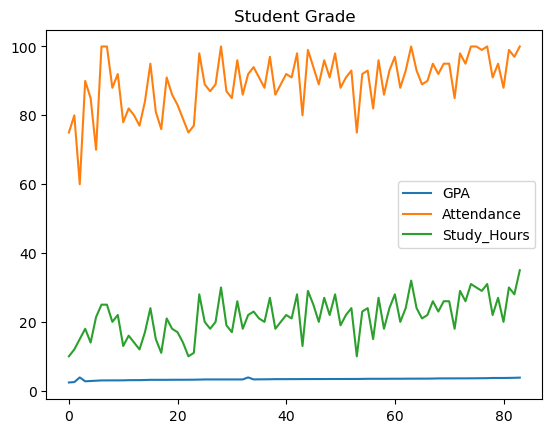

In [43]:
columns = data.columns.drop(['SAT'])
x_data = range(0 , data.shape[0])
fig, ax = plt.subplots()
for column in columns:
    ax.plot(x_data, data[column], label = column)
ax.set_title('Student Grade')
ax.legend()

**Linear regression**

In [44]:
data

,SAT,GPA,Attendance,Study_Hours
0,1714.0,2.400000,75,10.0
1,1664.0,2.520000,80,12.0
2,1760.0,3.868353,60,15.0
3,1685.0,2.740000,90,18.0
4,1693.0,2.830000,85,14.0
...,...,...,...,...
79,1936.0,3.710000,95,27.0
80,1810.0,3.710000,88,20.0
81,1987.0,3.730000,99,30.0
82,1962.0,3.760000,97,28.0


In [45]:
X = np.c_[data['SAT'],data['Attendance'],data['Study_Hours']]
y = np.c_[data['GPA']]

In [46]:
X

array([[1714.        ,   75.        ,   10.        ],
       [1664.        ,   80.        ,   12.        ],
       [1760.        ,   60.        ,   15.        ],
       [1685.        ,   90.        ,   18.        ],
       [1693.        ,   85.        ,   14.        ],
       [1826.08139535,   70.        ,   21.39534884],
       [1764.        ,  100.        ,   25.        ],
       [1764.        ,  100.        ,   25.        ],
       [1792.        ,   88.        ,   20.        ],
       [1850.        ,   92.        ,   22.        ],
       [1735.        ,   78.        ,   13.        ],
       [1775.        ,   82.        ,   16.        ],
       [1735.        ,   80.        ,   14.        ],
       [1712.        ,   77.        ,   12.        ],
       [1773.        ,   84.        ,   17.        ],
       [1872.        ,   95.        ,   24.        ],
       [1755.        ,   81.        ,   15.        ],
       [1674.        ,   76.        ,   11.        ],
       [1842.        ,   91.

In [47]:
y

array([[2.4       ],
       [2.52      ],
       [3.86835294],
       [2.74      ],
       [2.83      ],
       [2.91      ],
       [3.        ],
       [3.        ],
       [3.01      ],
       [3.01      ],
       [3.02      ],
       [3.07      ],
       [3.08      ],
       [3.08      ],
       [3.12      ],
       [3.17      ],
       [3.17      ],
       [3.17      ],
       [3.17      ],
       [3.19      ],
       [3.19      ],
       [3.19      ],
       [3.2       ],
       [3.21      ],
       [3.24      ],
       [3.28      ],
       [3.28      ],
       [3.28      ],
       [3.28      ],
       [3.28      ],
       [3.28      ],
       [3.28      ],
       [3.29      ],
       [3.86835294],
       [3.29      ],
       [3.31      ],
       [3.32      ],
       [3.34      ],
       [3.37      ],
       [3.37      ],
       [3.37      ],
       [3.38      ],
       [3.38      ],
       [3.39      ],
       [3.39      ],
       [3.4       ],
       [3.4       ],
       [3.4  

In [48]:
# normalized data
X_mean = np.mean(X,0)
X_normalized = X-X_mean
X_std = np.std(X,0)
X_normalized /=X_std
# add an additional column as 1 for X
m =y.size
X_normalized = np.c_[np.ones(m),X_normalized]

In [49]:
X_mean

array([1847.13192137,   89.63095238,   21.56423034])

In [50]:
X_std

array([102.13612102,   7.97731868,   5.79451137])

In [51]:
X_normalized

array([[ 1.        , -1.3034754 , -1.83406893, -1.9957214 ],
       [ 1.        , -1.79301818, -1.20729192, -1.65056719],
       [ 1.        , -0.85309605, -3.71439998, -1.13283587],
       [ 1.        , -1.58741021,  0.04626211, -0.61510456],
       [ 1.        , -1.50908337, -0.5805149 , -1.30541298],
       [ 1.        , -0.20610266, -2.46084595, -0.02914508],
       [ 1.        , -0.81393263,  1.29981615,  0.59293518],
       [ 1.        , -0.81393263,  1.29981615,  0.59293518],
       [ 1.        , -0.53978867, -0.20444869, -0.26995035],
       [ 1.        ,  0.02808094,  0.29697292,  0.07520387],
       [ 1.        , -1.09786744, -1.45800273, -1.47799008],
       [ 1.        , -0.70623322, -0.95658111, -0.96025877],
       [ 1.        , -1.09786744, -1.20729192, -1.30541298],
       [ 1.        , -1.32305711, -1.58335813, -1.65056719],
       [ 1.        , -0.72581493, -0.70587031, -0.78768166],
       [ 1.        ,  0.24347976,  0.67303913,  0.42035808],
       [ 1.        , -0.

In [52]:
# cost function
def computeCost(X,y,theta):
    m=y.size
    h=X.dot(theta)
    J=1/(2*m)*np.sum((h-y)**2)
    return(J)

In [53]:
computeCost(X_normalized,y,[[0],[0],[0],[0]])

5.657004815208436

In [54]:
def gradientDescent(X,y,theta, alpha=0.01, num_iters=50):
    m=y.size
    J_history=np.zeros(num_iters)
    for i in range(num_iters):
        h=X.dot(theta)
        #theta[0] = theta[0]-alpha*(1/m)*np.sum(h-y)
        #theta[1] = theta[1]-alpha*(1/m)*np.sum((h-y)*X[:,1:2])
        #theta[2] = theta[2]-alpha*(1/m)*np.sum((h-y)*X[:,2:3])
        #theta[4] = theta[3]-alpha*(1/m)*np.sum((h-y)*X[:,3:4])
        theta=theta-(alpha/m)*(X.T.dot(h-y))
        J_history[i] = computeCost(X,y,theta)
    return(theta,J_history)

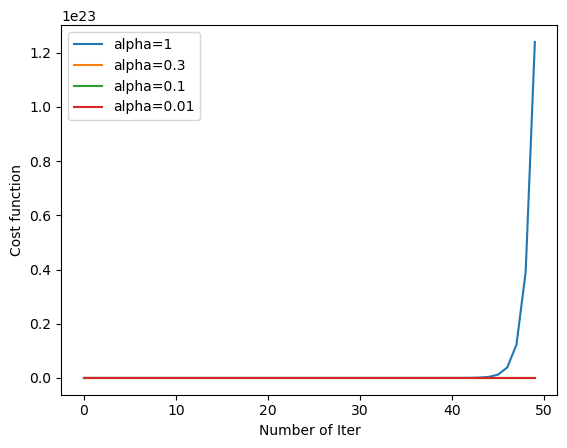

In [55]:
theta1,cost_J1=gradientDescent(X_normalized,y,[[0],[0],[0],[0]],1)
theta2,cost_J2=gradientDescent(X_normalized,y,[[0],[0],[0],[0]],0.3)
theta3,cost_J3=gradientDescent(X_normalized,y,[[0],[0],[0],[0]],0.1)
theta4,cost_J4=gradientDescent(X_normalized,y,[[0],[0],[0],[0]],0.01)
# plot
plt.plot(cost_J1,label='alpha=1')
plt.plot(cost_J2,label='alpha=0.3')
plt.plot(cost_J3,label='alpha=0.1')
plt.plot(cost_J4,label='alpha=0.01')
plt.xlabel('Number of Iter')
plt.ylabel('Cost function')
plt.legend()

In [56]:
new_data = np.c_[1700,80,15]

new_data_normalized=(new_data-X_mean)/X_std

new_data_normalized=np.c_[1,new_data_normalized]
print(new_data_normalized.dot(theta3))

[[3.14342549]]


**linear regression using Scikit-Learn**

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [89]:
# Define features (X) and target (y)
features = ['SAT', 'Attendance', 'Study_Hours']
X = data[features]
y = data['GPA']
print(data.tail())
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

       SAT   GPA  Attendance  Study_Hours
79  1936.0  3.71          95         27.0
80  1810.0  3.71          88         20.0
81  1987.0  3.73          99         30.0
82  1962.0  3.76          97         28.0
83  2050.0  3.81         100         35.0


In [90]:
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the training parameters
X_test_scaled = scaler.transform(X_test)

In [82]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate the model accuracy
print(f"R-squared Score on Test Set: {model.score(X_test_scaled, y_test):.4f}")

R-squared Score on Test Set: 0.2545


In [83]:
# Use the scaled TEST data you created earlier
y_pred = model.predict(X_test_scaled) 

In [91]:
# Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Output the optimized parameters
print(f"Theta 0 (Intercept): {model.intercept_}")
print(f"Thetas 1, 2, 3 (Coefficients): {model.coef_}")

Theta 0 (Intercept): 3.3608709394205447
Thetas 1, 2, 3 (Coefficients): [ 0.26889645 -0.08260842 -0.07464827]


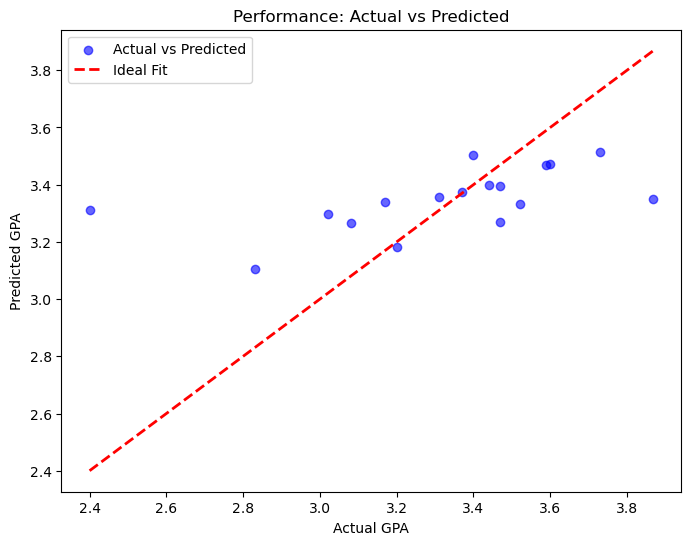

In [93]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Actual vs Predicted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Performance: Actual vs Predicted')
plt.legend()
plt.show()

In [94]:
# Create a new student entry with proper column names
new_student = pd.DataFrame([[1700, 80, 15]], columns=['SAT', 'Attendance', 'Study_Hours'])

# Scale the new data using our existing scaler
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)
print(f"The predicted GPA is: {prediction[0]:.2f}")

The predicted GPA is: 3.16
